In [1]:
import os
import time
import copy
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.1+cpu


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

device = torch.device("cpu")

print("Device:", device)

Seed: 42
Device: cpu


In [4]:
DATA_DIR = Path(
    r"C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks"
    r"\Shreyash-Intelligence-SIG-Recs-2026"
    r"\mandatory-tasks\recommender-systems-cf-to-dlrm"
    r"\datasets"
)

print(DATA_DIR)
print("Exists:", DATA_DIR.exists())

C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets
Exists: True


In [5]:
print("Files inside dataset directory:\n")

for p in DATA_DIR.iterdir():
    print(p.name)


zip_files = list(DATA_DIR.glob("*.zip"))

for z in zip_files:
    print("ZIP:", z.name)


ZIP_PATH = DATA_DIR / "dataset (tasks 2 and 3).zip"

if ZIP_PATH.exists():
    print("ZIP found:", ZIP_PATH)
else:
    print("ZIP not found. Check filename from previous cell.")

Files inside dataset directory:

dataset (tasks 2 and 3).zip
README.md
task2_3_data
ZIP: dataset (tasks 2 and 3).zip
ZIP found: C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\dataset (tasks 2 and 3).zip


In [6]:
EXTRACT_DIR = DATA_DIR / "task3_extracted"

EXTRACT_DIR.mkdir(exist_ok=True)

if ZIP_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

print("Extraction completed.")


csv_files = list(EXTRACT_DIR.rglob("*.csv"))

print("CSV files found:")

for f in csv_files:
    print(f)

Extraction completed.
CSV files found:
C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task3_extracted\test.csv
C:\Users\shrey\OneDrive\Desktop\MY_Project\wec_rec_tasks\Shreyash-Intelligence-SIG-Recs-2026\mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\task3_extracted\train.csv


In [7]:
for f in csv_files:
    print("\nFILE:", f.name)
    
    temp = pd.read_csv(f, nrows=5)
    
    print("Shape preview:", temp.shape)
    print("Columns:")
    print(temp.columns.tolist())


FILE: test.csv
Shape preview: (5, 40)
Columns:
['label', 'integer_feature_1', 'integer_feature_2', 'integer_feature_3', 'integer_feature_4', 'integer_feature_5', 'integer_feature_6', 'integer_feature_7', 'integer_feature_8', 'integer_feature_9', 'integer_feature_10', 'integer_feature_11', 'integer_feature_12', 'integer_feature_13', 'categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3', 'categorical_feature_4', 'categorical_feature_5', 'categorical_feature_6', 'categorical_feature_7', 'categorical_feature_8', 'categorical_feature_9', 'categorical_feature_10', 'categorical_feature_11', 'categorical_feature_12', 'categorical_feature_13', 'categorical_feature_14', 'categorical_feature_15', 'categorical_feature_16', 'categorical_feature_17', 'categorical_feature_18', 'categorical_feature_19', 'categorical_feature_20', 'categorical_feature_21', 'categorical_feature_22', 'categorical_feature_23', 'categorical_feature_24', 'categorical_feature_25', 'categorical_feature_26'

In [8]:
TRAIN_PATH = next(f for f in csv_files if f.name.lower() == "train.csv")
TEST_PATH  = next(f for f in csv_files if f.name.lower() == "test.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (40000, 40)
Test shape : (10000, 40)


In [10]:
TARGET = "label"

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTarget distribution:")
print(train_df[TARGET].value_counts())

print("\nTarget proportion:")
print(train_df[TARGET].value_counts(normalize=True))

Train shape: (40000, 40)
Test shape : (10000, 40)

Target distribution:
label
0    38720
1     1280
Name: count, dtype: int64

Target proportion:
label
0    0.968
1    0.032
Name: proportion, dtype: float64


In [11]:
X = train_df.drop(columns=[TARGET]).copy()
y = train_df[TARGET].astype(np.float32).copy()

X_test = test_df.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", X_test.shape)

X shape: (40000, 39)
y shape: (40000,)
Test shape: (10000, 40)


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (32000, 39)
Validation: (8000, 39)
Test: (10000, 40)


In [13]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 26
Numerical: 13


In [14]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# Fill numerical missing values using TRAIN statistics only
numeric_medians = X_train[numerical_cols].median()

X_train[numerical_cols] = X_train[numerical_cols].fillna(numeric_medians)
X_val[numerical_cols] = X_val[numerical_cols].fillna(numeric_medians)
X_test[numerical_cols] = X_test[numerical_cols].fillna(numeric_medians)

In [15]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_cols]
)

X_val_num = scaler.transform(
    X_val[numerical_cols]
)

X_test_num = scaler.transform(
    X_test[numerical_cols]
)

X_train_num = X_train_num.astype(np.float32)
X_val_num = X_val_num.astype(np.float32)
X_test_num = X_test_num.astype(np.float32)

print(X_train_num.shape)
print(X_val_num.shape)
print(X_test_num.shape)

(32000, 13)
(8000, 13)
(10000, 13)


In [16]:
categorical_maps = {}
X_train_cat = []
X_val_cat = []
X_test_cat = []

for col in categorical_cols:
    
    train_values = X_train[col].fillna("__MISSING__").astype(str)
    val_values = X_val[col].fillna("__MISSING__").astype(str)
    test_values = X_test[col].fillna("__MISSING__").astype(str)
    
    unique_values = sorted(train_values.unique())
    
    # 0 reserved for UNK
    mapping = {
        value: idx + 1
        for idx, value in enumerate(unique_values)
    }
    
    categorical_maps[col] = mapping
    
    train_encoded = train_values.map(mapping).fillna(0).astype(np.int64)
    val_encoded = val_values.map(mapping).fillna(0).astype(np.int64)
    test_encoded = test_values.map(mapping).fillna(0).astype(np.int64)
    
    X_train_cat.append(train_encoded.values)
    X_val_cat.append(val_encoded.values)
    X_test_cat.append(test_encoded.values)

In [17]:
X_train_cat = np.stack(X_train_cat, axis=1)
X_val_cat = np.stack(X_val_cat, axis=1)
X_test_cat = np.stack(X_test_cat, axis=1)

print("Train categorical:", X_train_cat.shape)
print("Val categorical  :", X_val_cat.shape)
print("Test categorical :", X_test_cat.shape)

Train categorical: (32000, 26)
Val categorical  : (8000, 26)
Test categorical : (10000, 26)


In [18]:
embedding_cardinalities = []

for col in categorical_cols:
    cardinality = len(categorical_maps[col]) + 1
    embedding_cardinalities.append(cardinality)

print("Number of categorical fields:",
      len(embedding_cardinalities))

for col, card in zip(categorical_cols, embedding_cardinalities):
    print(f"{col:30s} -> {card}")

Number of categorical fields: 26
categorical_feature_1          -> 10858
categorical_feature_2          -> 3349
categorical_feature_3          -> 4586
categorical_feature_4          -> 1614
categorical_feature_5          -> 3643
categorical_feature_6          -> 4
categorical_feature_7          -> 2912
categorical_feature_8          -> 711
categorical_feature_9          -> 23
categorical_feature_10         -> 9625
categorical_feature_11         -> 4772
categorical_feature_12         -> 6821
categorical_feature_13         -> 10
categorical_feature_14         -> 821
categorical_feature_15         -> 1833
categorical_feature_16         -> 43
categorical_feature_17         -> 5
categorical_feature_18         -> 310
categorical_feature_19         -> 15
categorical_feature_20         -> 11112
categorical_feature_21         -> 7581
categorical_feature_22         -> 10423
categorical_feature_23         -> 4362
categorical_feature_24         -> 3258
categorical_feature_25         -> 36
categori

In [19]:
y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)

print("Train positives:", y_train_np.sum())
print("Val positives:", y_val_np.sum())

Train positives: 1024.0
Val positives: 256.0


In [20]:
num_positive = np.sum(y_train_np == 1)
num_negative = np.sum(y_train_np == 0)

pos_weight_value = num_negative / num_positive

print("Positive:", num_positive)
print("Negative:", num_negative)
print("pos_weight:", pos_weight_value)

Positive: 1024
Negative: 30976
pos_weight: 30.25


In [21]:
pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

In [22]:
class CTRDataset(Dataset):
    
    def __init__(self, numerical, categorical, targets=None):
        self.numerical = torch.tensor(
            numerical,
            dtype=torch.float32
        )
        
        self.categorical = torch.tensor(
            categorical,
            dtype=torch.long
        )
        
        self.targets = None
        
        if targets is not None:
            self.targets = torch.tensor(
                targets,
                dtype=torch.float32
            )
    
    def __len__(self):
        return len(self.numerical)
    
    def __getitem__(self, idx):
        
        if self.targets is not None:
            return (
                self.numerical[idx],
                self.categorical[idx],
                self.targets[idx]
            )
        
        return (
            self.numerical[idx],
            self.categorical[idx]
        )

In [23]:
BATCH_SIZE = 2048

train_dataset = CTRDataset(
    X_train_num,
    X_train_cat,
    y_train_np
)

val_dataset = CTRDataset(
    X_val_num,
    X_val_cat,
    y_val_np
)

test_dataset = CTRDataset(
    X_test_num,
    X_test_cat
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 16
Val batches: 4
Test batches: 5


In [24]:
class BottomMLP(nn.Module):
    
    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dims=(64, 32),
        dropout=0.1
    ):
        super().__init__()
        
        layers = []
        
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            
            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )
            
            layers.append(
                nn.ReLU()
            )
            
            layers.append(
                nn.BatchNorm1d(hidden_dim)
            )
            
            layers.append(
                nn.Dropout(dropout)
            )
            
            prev_dim = hidden_dim
        
        # Final projection to embedding dimension
        layers.append(
            nn.Linear(prev_dim, embedding_dim)
        )
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [25]:
class InteractionLayer(nn.Module):
    
    def __init__(self, num_fields):
        super().__init__()
        
        self.num_fields = num_fields
        
        # Upper triangular indices excluding diagonal
        rows, cols = torch.triu_indices(
            num_fields,
            num_fields,
            offset=1
        )
        
        self.register_buffer("rows", rows)
        self.register_buffer("cols", cols)
    
    def forward(self, dense_vector, embeddings):
        """
        dense_vector:
            [batch_size, embedding_dim]
        
        embeddings:
            [batch_size, num_categorical_fields, embedding_dim]
        """
        
        # Add dense vector as one additional field
        dense_vector = dense_vector.unsqueeze(1)
        
        # [B, 27, D]
        features = torch.cat(
            [dense_vector, embeddings],
            dim=1
        )
        
        # [B, 27, 27]
        interaction_matrix = torch.bmm(
            features,
            features.transpose(1, 2)
        )
        
        # Extract upper triangular pairwise interactions
        interactions = interaction_matrix[
            :,
            self.rows,
            self.cols
        ]
        
        return interactions

In [26]:
class DLRM(nn.Module):
    
    def __init__(
        self,
        num_numerical_features,
        embedding_cardinalities,
        embedding_dim=16,
        bottom_mlp_dims=(64, 32),
        top_mlp_dims=(128, 64),
        dropout=0.2,
        use_interactions=True
    ):
        super().__init__()
        
        self.num_categorical = len(
            embedding_cardinalities
        )
        
        self.embedding_dim = embedding_dim
        self.use_interactions = use_interactions
        
        # ------------------------------------------------
        # Embedding tables
        # ------------------------------------------------
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=cardinality,
                embedding_dim=embedding_dim
            )
            for cardinality in embedding_cardinalities
        ])
        
        # ------------------------------------------------
        # Bottom MLP
        # ------------------------------------------------
        
        self.bottom_mlp = BottomMLP(
            input_dim=num_numerical_features,
            embedding_dim=embedding_dim,
            hidden_dims=bottom_mlp_dims,
            dropout=dropout
        )
        
        # ------------------------------------------------
        # Interaction
        # ------------------------------------------------
        
        if use_interactions:
            
            self.interaction_layer = InteractionLayer(
                num_fields=self.num_categorical + 1
            )
            
            num_interactions = (
                (self.num_categorical + 1)
                * self.num_categorical
                // 2
            )
            
            top_input_dim = (
                embedding_dim +
                num_interactions
            )
        
        else:
            
            self.interaction_layer = None
            
            # Ablation:
            # dense vector + all categorical embeddings
            top_input_dim = (
                embedding_dim +
                self.num_categorical * embedding_dim
            )
        
        # ------------------------------------------------
        # Top MLP
        # ------------------------------------------------
        
        top_layers = []
        
        prev_dim = top_input_dim
        
        for hidden_dim in top_mlp_dims:
            
            top_layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )
            
            top_layers.append(
                nn.ReLU()
            )
            
            top_layers.append(
                nn.BatchNorm1d(hidden_dim)
            )
            
            top_layers.append(
                nn.Dropout(dropout)
            )
            
            prev_dim = hidden_dim
        
        # Final output = logit
        top_layers.append(
            nn.Linear(prev_dim, 1)
        )
        
        self.top_mlp = nn.Sequential(*top_layers)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        
        for embedding in self.embeddings:
            nn.init.normal_(
                embedding.weight,
                mean=0.0,
                std=0.01
            )
        
        for module in self.modules():
            
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(
                    module.weight
                )
                
                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )
    
    def forward(self, numerical, categorical):
        
        # ------------------------------------------------
        # Dense pathway
        # ------------------------------------------------
        
        dense_vector = self.bottom_mlp(
            numerical
        )
        
        # ------------------------------------------------
        # Categorical embeddings
        # ------------------------------------------------
        
        embedding_vectors = []
        
        for i, embedding in enumerate(self.embeddings):
            
            embedding_vectors.append(
                embedding(
                    categorical[:, i]
                )
            )
        
        # [B, 26, D]
        embedding_vectors = torch.stack(
            embedding_vectors,
            dim=1
        )
        
        # ------------------------------------------------
        # Interaction
        # ------------------------------------------------
        
        if self.use_interactions:
            
            interactions = self.interaction_layer(
                dense_vector,
                embedding_vectors
            )
            
            # [B, D + interactions]
            top_input = torch.cat(
                [
                    dense_vector,
                    interactions
                ],
                dim=1
            )
        
        else:
            
            # Ablation model
            flattened_embeddings = embedding_vectors.flatten(
                start_dim=1
            )
            
            top_input = torch.cat(
                [
                    dense_vector,
                    flattened_embeddings
                ],
                dim=1
            )
        
        # ------------------------------------------------
        # Final prediction
        # ------------------------------------------------
        
        logit = self.top_mlp(
            top_input
        )
        
        return logit.squeeze(1)

In [27]:
EMBEDDING_DIM = 16

dlrm = DLRM(
    num_numerical_features=len(numerical_cols),
    embedding_cardinalities=embedding_cardinalities,
    embedding_dim=EMBEDDING_DIM,
    bottom_mlp_dims=(64, 32),
    top_mlp_dims=(128, 64),
    dropout=0.20,
    use_interactions=True
).to(device)

print(dlrm)

DLRM(
  (embeddings): ModuleList(
    (0): Embedding(10858, 16)
    (1): Embedding(3349, 16)
    (2): Embedding(4586, 16)
    (3): Embedding(1614, 16)
    (4): Embedding(3643, 16)
    (5): Embedding(4, 16)
    (6): Embedding(2912, 16)
    (7): Embedding(711, 16)
    (8): Embedding(23, 16)
    (9): Embedding(9625, 16)
    (10): Embedding(4772, 16)
    (11): Embedding(6821, 16)
    (12): Embedding(10, 16)
    (13): Embedding(821, 16)
    (14): Embedding(1833, 16)
    (15): Embedding(43, 16)
    (16): Embedding(5, 16)
    (17): Embedding(310, 16)
    (18): Embedding(15, 16)
    (19): Embedding(11112, 16)
    (20): Embedding(7581, 16)
    (21): Embedding(10423, 16)
    (22): Embedding(4362, 16)
    (23): Embedding(3258, 16)
    (24): Embedding(36, 16)
    (25): Embedding(25, 16)
  )
  (bottom_mlp): BottomMLP(
    (network): Sequential(
      (0): Linear(in_features=13, out_features=64, bias=True)
      (1): ReLU()
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, 

In [28]:
batch = next(iter(train_loader))

numerical_batch, categorical_batch, target_batch = batch

numerical_batch = numerical_batch.to(device)
categorical_batch = categorical_batch.to(device)

with torch.no_grad():
    output = dlrm(
        numerical_batch,
        categorical_batch
    )

print("Numerical shape:", numerical_batch.shape)
print("Categorical shape:", categorical_batch.shape)
print("Output shape:", output.shape)

Numerical shape: torch.Size([2048, 13])
Categorical shape: torch.Size([2048, 26])
Output shape: torch.Size([2048])


In [29]:
num_fields = len(categorical_cols) + 1

num_interactions = (
    num_fields * (num_fields - 1)
) // 2

print("Categorical fields:", len(categorical_cols))
print("Dense field:", 1)
print("Total interaction fields:", num_fields)
print("Pairwise interactions:", num_interactions)

Categorical fields: 26
Dense field: 1
Total interaction fields: 27
Pairwise interactions: 351


In [30]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

total_params = count_parameters(dlrm)

print(
    f"Trainable parameters: {total_params:,}"
)

Trainable parameters: 1,479,537


In [31]:
embedding_params = sum(
    p.numel()
    for name, p in dlrm.named_parameters()
    if "embeddings" in name
)

other_params = total_params - embedding_params

print("Embedding parameters:", f"{embedding_params:,}")
print("Other parameters:", f"{other_params:,}")
print("Total:", f"{total_params:,}")

Embedding parameters: 1,420,032
Other parameters: 59,505
Total: 1,479,537


In [32]:
param_memory_mb = (
    total_params * 4
) / (1024 ** 2)

print(
    f"Approx parameter memory: {param_memory_mb:.2f} MB"
)

Approx parameter memory: 5.64 MB


In [33]:
def evaluate_model(
    model,
    loader,
    criterion,
    device
):
    
    model.eval()
    
    total_loss = 0.0
    total_samples = 0
    
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        
        for batch in loader:
            
            numerical = batch[0].to(device)
            categorical = batch[1].to(device)
            targets = batch[2].to(device)
            
            logits = model(
                numerical,
                categorical
            )
            
            loss = criterion(
                logits,
                targets
            )
            
            batch_size = targets.size(0)
            
            total_loss += (
                loss.item() * batch_size
            )
            
            total_samples += batch_size
            
            probs = torch.sigmoid(
                logits
            )
            
            all_targets.append(
                targets.cpu().numpy()
            )
            
            all_probs.append(
                probs.cpu().numpy()
            )
    
    avg_loss = total_loss / total_samples
    
    y_true = np.concatenate(
        all_targets
    )
    
    y_prob = np.concatenate(
        all_probs
    )
    
    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )
    
    pr_auc = average_precision_score(
        y_true,
        y_prob
    )
    
    return {
        "loss": avg_loss,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "y_true": y_true,
        "y_prob": y_prob
    }

In [36]:
def train_dlrm(
    model,
    train_loader,
    val_loader,
    pos_weight,
    device,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-5,
    patience=2
):
    
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_auc": [],
        "val_auc": [],
        "train_pr_auc": [],
        "val_pr_auc": []
    }
    
    best_auc = -np.inf
    best_state = None
    patience_counter = 0
    
    start_time = time.perf_counter()
    
    for epoch in range(1, epochs + 1):
        
        epoch_start = time.perf_counter()
        
        model.train()
        
        total_loss = 0.0
        total_samples = 0
        
        all_train_targets = []
        all_train_probs = []
        
        for numerical, categorical, targets in train_loader:
            
            numerical = numerical.to(device)
            categorical = categorical.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            
            logits = model(
                numerical,
                categorical
            )
            
            loss = criterion(
                logits,
                targets
            )
            
            loss.backward()
            
            optimizer.step()
            
            batch_size = targets.size(0)
            
            total_loss += (
                loss.item() * batch_size
            )
            
            total_samples += batch_size
            
            probs = torch.sigmoid(
                logits.detach()
            )
            
            all_train_targets.append(
                targets.detach().cpu().numpy()
            )
            
            all_train_probs.append(
                probs.cpu().numpy()
            )
        
        train_loss = (
            total_loss /
            total_samples
        )
        
        train_targets = np.concatenate(
            all_train_targets
        )
        
        train_probs = np.concatenate(
            all_train_probs
        )
        
        train_auc = roc_auc_score(
            train_targets,
            train_probs
        )
        
        train_pr_auc = average_precision_score(
            train_targets,
            train_probs
        )
        
        val_metrics = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )
        
        history["train_loss"].append(
            train_loss
        )
        
        history["val_loss"].append(
            val_metrics["loss"]
        )
        
        history["train_auc"].append(
            train_auc
        )
        
        history["val_auc"].append(
            val_metrics["roc_auc"]
        )
        
        history["train_pr_auc"].append(
            train_pr_auc
        )
        
        history["val_pr_auc"].append(
            val_metrics["pr_auc"]
        )
        
        epoch_time = (
            time.perf_counter() -
            epoch_start
        )
        
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train AUC: {train_auc:.4f} | "
            f"Val AUC: {val_metrics['roc_auc']:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )
        
        # ---------------------------------------------
        # Early stopping based on validation ROC-AUC
        # ---------------------------------------------
        
        if val_metrics["roc_auc"] > best_auc:
            
            best_auc = val_metrics["roc_auc"]
            
            best_state = copy.deepcopy(
                model.state_dict()
            )
            
            patience_counter = 0
            
            print("Best model saved")
        
        else:
            
            patience_counter += 1
            
            print(
                f"   No improvement "
                f"({patience_counter}/{patience})"
            )
            
            if patience_counter >= patience:
                
                print(
                    " Early stopping"
                )
                
                break
    
    total_time = (
        time.perf_counter() -
        start_time
    )
    
    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
    
    return model, history, total_time

In [37]:
dlrm, dlrm_history, dlrm_time = train_dlrm(
    model=dlrm,
    train_loader=train_loader,
    val_loader=val_loader,
    pos_weight=pos_weight,
    device=device,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-5,
    patience=2
)

print(
    f"\nTotal DLRM training time: "
    f"{dlrm_time:.2f} seconds"
)

Epoch 01 | Train Loss: 1.3293 | Val Loss: 1.2590 | Train AUC: 0.6470 | Val AUC: 0.6663 | Val PR-AUC: 0.0638 | Time: 1.7s
Best model saved
Epoch 02 | Train Loss: 1.2135 | Val Loss: 1.2859 | Train AUC: 0.7451 | Val AUC: 0.6460 | Val PR-AUC: 0.0586 | Time: 3.7s
   No improvement (1/2)
Epoch 03 | Train Loss: 0.9920 | Val Loss: 1.3593 | Train AUC: 0.8481 | Val AUC: 0.6411 | Val PR-AUC: 0.0560 | Time: 3.9s
   No improvement (2/2)
 Early stopping

Total DLRM training time: 9.34 seconds


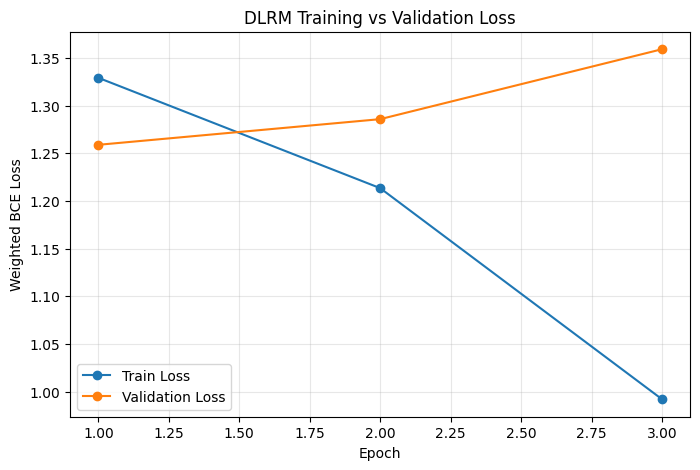

In [38]:
epochs_ran = range(
    1,
    len(dlrm_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    dlrm_history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_ran,
    dlrm_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted BCE Loss")
plt.title("DLRM Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

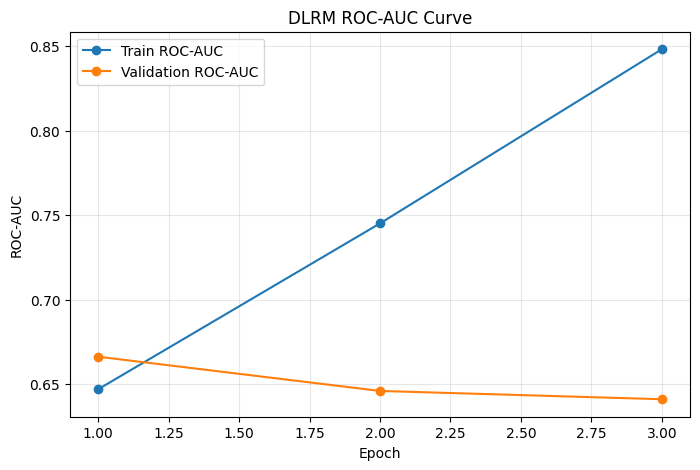

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    dlrm_history["train_auc"],
    marker="o",
    label="Train ROC-AUC"
)

plt.plot(
    epochs_ran,
    dlrm_history["val_auc"],
    marker="o",
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("DLRM ROC-AUC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

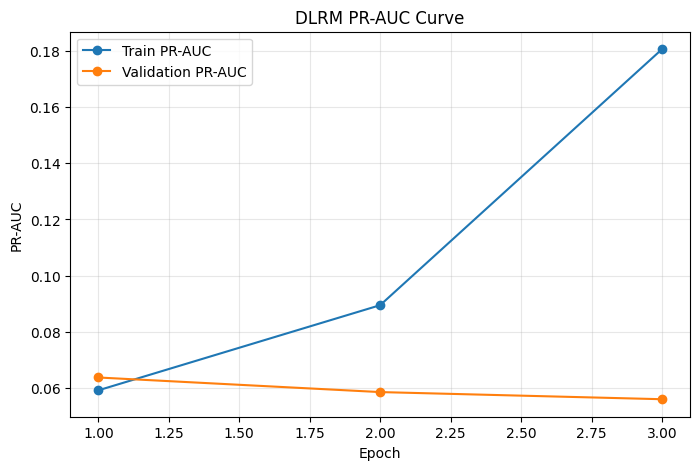

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    dlrm_history["train_pr_auc"],
    marker="o",
    label="Train PR-AUC"
)

plt.plot(
    epochs_ran,
    dlrm_history["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("DLRM PR-AUC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [41]:
best_epoch_idx = np.argmax(
    dlrm_history["val_auc"]
)

best_val_auc = dlrm_history[
    "val_auc"
][best_epoch_idx]

best_val_pr_auc = dlrm_history[
    "val_pr_auc"
][best_epoch_idx]

print(
    "Best epoch:",
    best_epoch_idx + 1
)

print(
    "Best validation ROC-AUC:",
    round(best_val_auc, 5)
)

print(
    "Validation PR-AUC:",
    round(best_val_pr_auc, 5)
)

Best epoch: 1
Best validation ROC-AUC: 0.66627
Validation PR-AUC: 0.06377


In [42]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

val_metrics = evaluate_model(
    dlrm,
    val_loader,
    criterion,
    device
)

y_val_true = val_metrics["y_true"]
y_val_prob = val_metrics["y_prob"]

print(
    "Validation ROC-AUC:",
    roc_auc_score(
        y_val_true,
        y_val_prob
    )
)

print(
    "Validation PR-AUC:",
    average_precision_score(
        y_val_true,
        y_val_prob
    )
)

Validation ROC-AUC: 0.666266827543905
Validation PR-AUC: 0.06377071743949192


In [43]:
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

threshold_results = []

for threshold in thresholds:
    
    y_pred = (
        y_val_prob >= threshold
    ).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "f1": f1_score(
            y_val_true,
            y_pred,
            zero_division=0
        ),
        "precision": precision_score(
            y_val_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val_true,
            y_pred,
            zero_division=0
        ),
        "accuracy": accuracy_score(
            y_val_true,
            y_pred
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold = best_threshold_row[
    "threshold"
]

print(best_threshold_row)

threshold    0.620000
f1           0.120354
precision    0.077803
recall       0.265625
accuracy     0.875750
Name: 57, dtype: float64


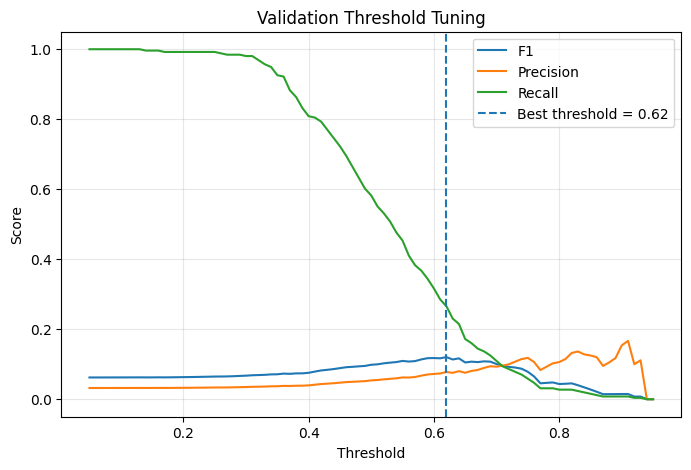

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Tuning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
val_pred = (
    y_val_prob >= best_threshold
).astype(int)

val_results = {
    "ROC-AUC": roc_auc_score(
        y_val_true,
        y_val_prob
    ),
    
    "PR-AUC": average_precision_score(
        y_val_true,
        y_val_prob
    ),
    
    "Accuracy": accuracy_score(
        y_val_true,
        val_pred
    ),
    
    "Precision": precision_score(
        y_val_true,
        val_pred,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_val_true,
        val_pred,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_val_true,
        val_pred,
        zero_division=0
    ),
    
    "Log Loss": log_loss(
        y_val_true,
        y_val_prob
    ),
    
    "Brier Score": brier_score_loss(
        y_val_true,
        y_val_prob
    ),
    
    "Threshold": best_threshold
}

pd.DataFrame(
    [val_results]
)

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Log Loss,Brier Score,Threshold
0,0.666267,0.063771,0.87575,0.077803,0.265625,0.120354,0.638521,0.222781,0.62


In [46]:
dlrm.eval()

test_probs = []

with torch.no_grad():
    
    for numerical, categorical in test_loader:
        
        numerical = numerical.to(device)
        categorical = categorical.to(device)
        
        logits = dlrm(
            numerical,
            categorical
        )
        
        probs = torch.sigmoid(
            logits
        )
        
        test_probs.append(
            probs.cpu().numpy()
        )

test_probs = np.concatenate(
    test_probs
)

print("Test predictions:", test_probs.shape)
print(test_probs[:10])

Test predictions: (10000,)
[0.4398937  0.6600454  0.4429673  0.06165922 0.35611117 0.32789645
 0.69114715 0.53961265 0.5868911  0.47927463]


In [47]:
if TARGET in test_df.columns:
    
    y_test_true = test_df[TARGET].astype(
        np.float32
    ).to_numpy()
    
    y_test_pred = (
        test_probs >= best_threshold
    ).astype(int)
    
    test_results = {
        "ROC-AUC": roc_auc_score(
            y_test_true,
            test_probs
        ),
        "PR-AUC": average_precision_score(
            y_test_true,
            test_probs
        ),
        "Accuracy": accuracy_score(
            y_test_true,
            y_test_pred
        ),
        "Precision": precision_score(
            y_test_true,
            y_test_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_true,
            y_test_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_true,
            y_test_pred,
            zero_division=0
        ),
        "Log Loss": log_loss(
            y_test_true,
            test_probs
        ),
        "Brier Score": brier_score_loss(
            y_test_true,
            test_probs
        )
    }
    
    display(
        pd.DataFrame([test_results])
    )

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Log Loss,Brier Score
0,0.655129,0.060652,0.8716,0.078222,0.262687,0.120548,0.646849,0.226288


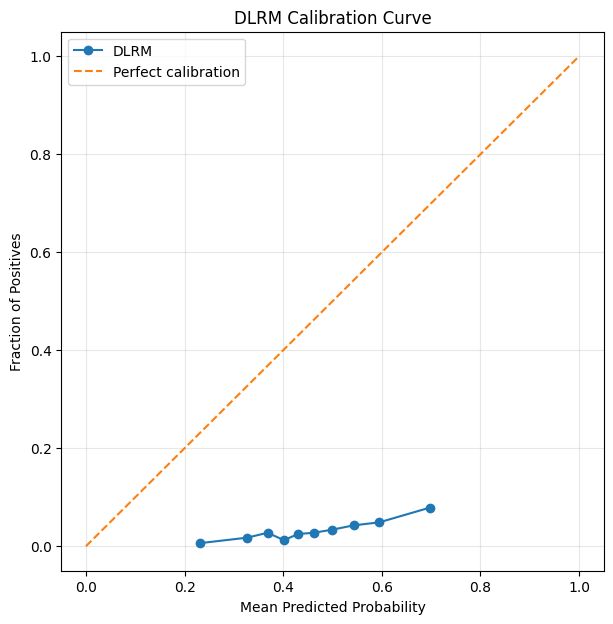

In [48]:
prob_true, prob_pred = calibration_curve(
    y_val_true,
    y_val_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="DLRM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("DLRM Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

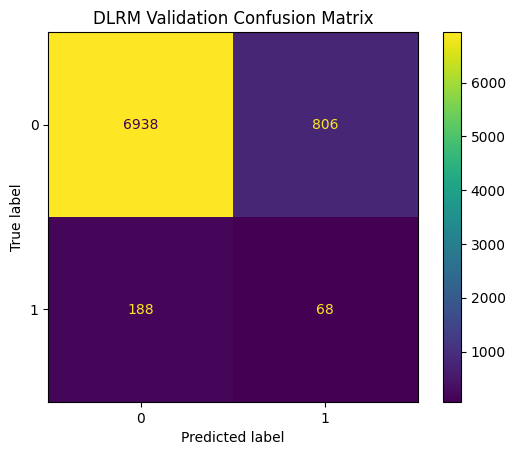

In [49]:
cm = confusion_matrix(
    y_val_true,
    val_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "DLRM Validation Confusion Matrix"
)

plt.show()

## Ablation Model

In [50]:
dlrm_no_interaction = DLRM(
    num_numerical_features=len(numerical_cols),
    embedding_cardinalities=embedding_cardinalities,
    embedding_dim=EMBEDDING_DIM,
    bottom_mlp_dims=(64, 32),
    top_mlp_dims=(128, 64),
    dropout=0.20,
    use_interactions=False
).to(device)

print(dlrm_no_interaction)

DLRM(
  (embeddings): ModuleList(
    (0): Embedding(10858, 16)
    (1): Embedding(3349, 16)
    (2): Embedding(4586, 16)
    (3): Embedding(1614, 16)
    (4): Embedding(3643, 16)
    (5): Embedding(4, 16)
    (6): Embedding(2912, 16)
    (7): Embedding(711, 16)
    (8): Embedding(23, 16)
    (9): Embedding(9625, 16)
    (10): Embedding(4772, 16)
    (11): Embedding(6821, 16)
    (12): Embedding(10, 16)
    (13): Embedding(821, 16)
    (14): Embedding(1833, 16)
    (15): Embedding(43, 16)
    (16): Embedding(5, 16)
    (17): Embedding(310, 16)
    (18): Embedding(15, 16)
    (19): Embedding(11112, 16)
    (20): Embedding(7581, 16)
    (21): Embedding(10423, 16)
    (22): Embedding(4362, 16)
    (23): Embedding(3258, 16)
    (24): Embedding(36, 16)
    (25): Embedding(25, 16)
  )
  (bottom_mlp): BottomMLP(
    (network): Sequential(
      (0): Linear(in_features=13, out_features=64, bias=True)
      (1): ReLU()
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, 

In [51]:
full_params = count_parameters(dlrm)

ablation_params = count_parameters(
    dlrm_no_interaction
)

print(
    "Full DLRM:",
    f"{full_params:,}"
)

print(
    "No-interaction:",
    f"{ablation_params:,}"
)

Full DLRM: 1,479,537
No-interaction: 1,487,857


In [52]:
dlrm_no_interaction, ablation_history, ablation_time = train_dlrm(
    model=dlrm_no_interaction,
    train_loader=train_loader,
    val_loader=val_loader,
    pos_weight=pos_weight,
    device=device,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-5,
    patience=2
)

print(
    f"\nAblation training time: "
    f"{ablation_time:.2f} seconds"
)

Epoch 01 | Train Loss: 1.5779 | Val Loss: 1.3632 | Train AUC: 0.5321 | Val AUC: 0.6757 | Val PR-AUC: 0.0638 | Time: 1.6s
Best model saved
Epoch 02 | Train Loss: 1.4196 | Val Loss: 1.2616 | Train AUC: 0.6219 | Val AUC: 0.6882 | Val PR-AUC: 0.0699 | Time: 2.8s
Best model saved
Epoch 03 | Train Loss: 1.2557 | Val Loss: 1.2174 | Train AUC: 0.7178 | Val AUC: 0.7019 | Val PR-AUC: 0.0798 | Time: 3.3s
Best model saved
Epoch 04 | Train Loss: 1.0989 | Val Loss: 1.3361 | Train AUC: 0.8133 | Val AUC: 0.6856 | Val PR-AUC: 0.0747 | Time: 4.4s
   No improvement (1/2)
Epoch 05 | Train Loss: 0.8669 | Val Loss: 1.4777 | Train AUC: 0.9036 | Val AUC: 0.6551 | Val PR-AUC: 0.0583 | Time: 4.8s
   No improvement (2/2)
 Early stopping

Ablation training time: 16.96 seconds


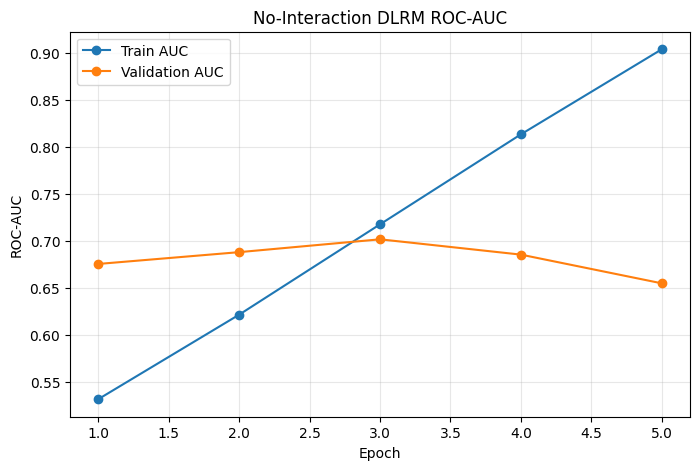

In [53]:
epochs_ablation = range(
    1,
    len(ablation_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ablation,
    ablation_history["train_auc"],
    marker="o",
    label="Train AUC"
)

plt.plot(
    epochs_ablation,
    ablation_history["val_auc"],
    marker="o",
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title(
    "No-Interaction DLRM ROC-AUC"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [54]:
ablation_val_metrics = evaluate_model(
    dlrm_no_interaction,
    val_loader,
    criterion,
    device
)

ablation_y_val_true = (
    ablation_val_metrics["y_true"]
)

ablation_y_val_prob = (
    ablation_val_metrics["y_prob"]
)

ablation_auc = roc_auc_score(
    ablation_y_val_true,
    ablation_y_val_prob
)

ablation_pr_auc = average_precision_score(
    ablation_y_val_true,
    ablation_y_val_prob
)

print(
    "Ablation ROC-AUC:",
    round(ablation_auc, 5)
)

print(
    "Ablation PR-AUC:",
    round(ablation_pr_auc, 5)
)

Ablation ROC-AUC: 0.70185
Ablation PR-AUC: 0.0798


In [55]:
ablation_threshold_results = []

for threshold in thresholds:
    
    preds = (
        ablation_y_val_prob >= threshold
    ).astype(int)
    
    ablation_threshold_results.append({
        "threshold": threshold,
        "f1": f1_score(
            ablation_y_val_true,
            preds,
            zero_division=0
        ),
        "precision": precision_score(
            ablation_y_val_true,
            preds,
            zero_division=0
        ),
        "recall": recall_score(
            ablation_y_val_true,
            preds,
            zero_division=0
        )
    })

ablation_threshold_df = pd.DataFrame(
    ablation_threshold_results
)

best_ablation_row = (
    ablation_threshold_df.loc[
        ablation_threshold_df["f1"].idxmax()
    ]
)

best_ablation_threshold = (
    best_ablation_row["threshold"]
)

ablation_pred = (
    ablation_y_val_prob >=
    best_ablation_threshold
).astype(int)

ablation_results = {
    "Model": "DLRM - No Interactions",
    
    "ROC-AUC": ablation_auc,
    
    "PR-AUC": ablation_pr_auc,
    
    "Accuracy": accuracy_score(
        ablation_y_val_true,
        ablation_pred
    ),
    
    "Precision": precision_score(
        ablation_y_val_true,
        ablation_pred,
        zero_division=0
    ),
    
    "Recall": recall_score(
        ablation_y_val_true,
        ablation_pred,
        zero_division=0
    ),
    
    "F1": f1_score(
        ablation_y_val_true,
        ablation_pred,
        zero_division=0
    ),
    
    "Log Loss": log_loss(
        ablation_y_val_true,
        ablation_y_val_prob
    ),
    
    "Brier Score": brier_score_loss(
        ablation_y_val_true,
        ablation_y_val_prob
    ),
    
    "Threshold": best_ablation_threshold,
    
    "Training Time (sec)": ablation_time,
    
    "Parameters": ablation_params
}

pd.DataFrame([ablation_results])

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Log Loss,Brier Score,Threshold,Training Time (sec),Parameters
0,DLRM - No Interactions,0.701852,0.079798,0.94575,0.162879,0.167969,0.165385,0.638714,0.222678,0.77,16.960584,1487857


In [56]:
full_dlrm_results = {
    "Model": "DLRM",
    
    "ROC-AUC": val_results["ROC-AUC"],
    
    "PR-AUC": val_results["PR-AUC"],
    
    "Accuracy": val_results["Accuracy"],
    
    "Precision": val_results["Precision"],
    
    "Recall": val_results["Recall"],
    
    "F1": val_results["F1"],
    
    "Log Loss": val_results["Log Loss"],
    
    "Brier Score": val_results["Brier Score"],
    
    "Threshold": val_results["Threshold"],
    
    "Training Time (sec)": dlrm_time,
    
    "Parameters": full_params
}

In [57]:
dlrm_comparison = pd.DataFrame([
    full_dlrm_results,
    ablation_results
])

dlrm_comparison

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Log Loss,Brier Score,Threshold,Training Time (sec),Parameters
0,DLRM,0.666267,0.063771,0.87575,0.077803,0.265625,0.120354,0.638521,0.222781,0.62,9.340857,1479537
1,DLRM - No Interactions,0.701852,0.079798,0.94575,0.162879,0.167969,0.165385,0.638714,0.222678,0.77,16.960584,1487857


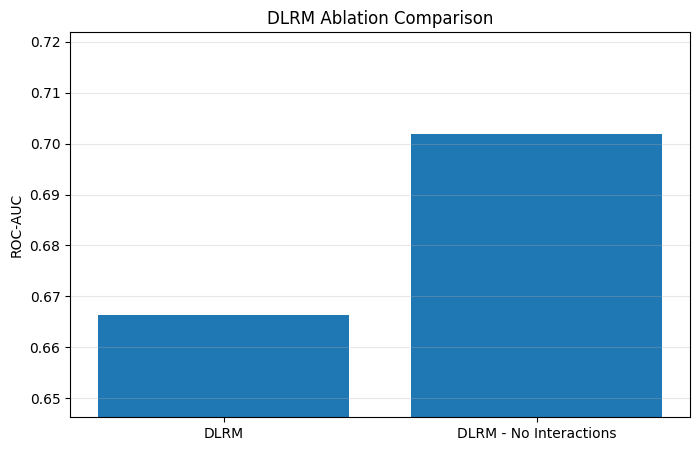

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    dlrm_comparison["Model"],
    dlrm_comparison["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title(
    "DLRM Ablation Comparison"
)

plt.ylim(
    min(dlrm_comparison["ROC-AUC"]) - 0.02,
    max(dlrm_comparison["ROC-AUC"]) + 0.02
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [59]:
task2_best_result = {
    "Model": "Task 2 - Best Vanilla NN",
    "ROC-AUC": 0.687050,
    "PR-AUC": 0.066866,
    "Accuracy": 0.68800,
    "F1": 0.106017,
    "Log Loss": 0.620450
}

In [60]:
comparison_rows = [
    task2_best_result,
    full_dlrm_results,
    ablation_results
]

final_comparison = pd.DataFrame(
    comparison_rows
)

final_comparison

,Model,ROC-AUC,PR-AUC,Accuracy,F1,Log Loss,Precision,Recall,Brier Score,Threshold,Training Time (sec),Parameters
0,Task 2 - Best Vanilla NN,0.687050,0.066866,0.68800,0.106017,0.620450,NaN,NaN,NaN,NaN,NaN,NaN
1,DLRM,0.666267,0.063771,0.87575,0.120354,0.638521,0.077803,0.265625,0.222781,0.62,9.340857,1479537.0
2,DLRM - No Interactions,0.701852,0.079798,0.94575,0.165385,0.638714,0.162879,0.167969,0.222678,0.77,16.960584,1487857.0


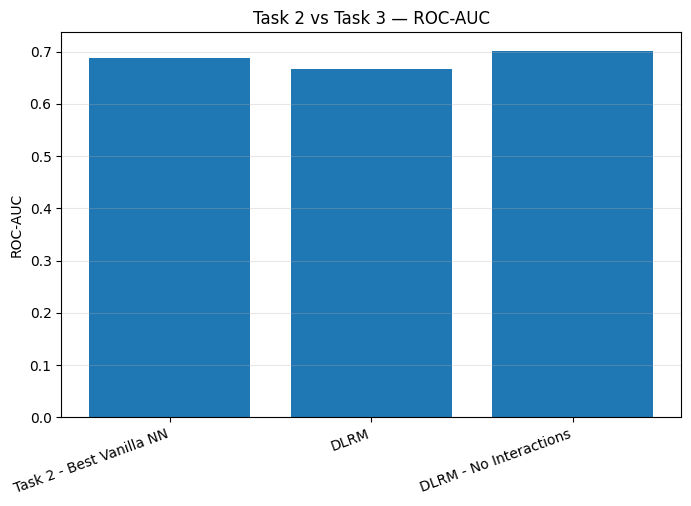

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title(
    "Task 2 vs Task 3 — ROC-AUC"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

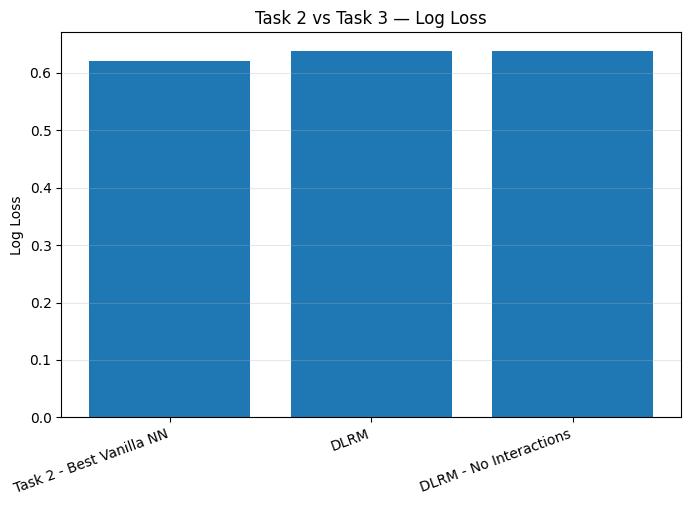

In [62]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Log Loss"]
)

plt.ylabel("Log Loss")
plt.title(
    "Task 2 vs Task 3 — Log Loss"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

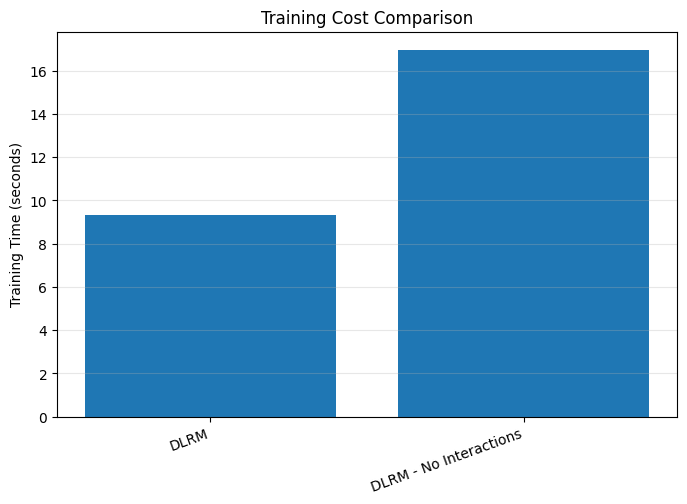

In [63]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Training Time (sec)"]
)

plt.ylabel("Training Time (seconds)")
plt.title(
    "Training Cost Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

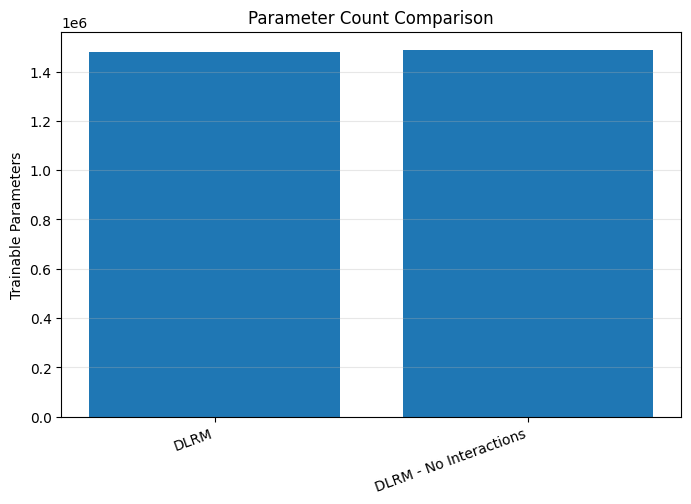

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Parameters"]
)

plt.ylabel("Trainable Parameters")
plt.title(
    "Parameter Count Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [65]:
MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)

torch.save(
    {
        "model_state_dict": dlrm.state_dict(),
        "embedding_cardinalities": embedding_cardinalities,
        "embedding_dim": EMBEDDING_DIM,
        "numerical_cols": numerical_cols,
        "categorical_cols": categorical_cols,
        "best_threshold": float(best_threshold),
        "seed": SEED
    },
    MODEL_DIR / "dlrm_model.pt"
)

print(
    "Saved:",
    MODEL_DIR / "dlrm_model.pt"
)

Saved: saved_models\dlrm_model.pt


In [66]:
submission = pd.DataFrame({
    "prediction": test_probs
})

submission_path = Path(
    "dlrm_test_predictions.csv"
)

submission.to_csv(
    submission_path,
    index=False
)

print(
    "Saved:",
    submission_path
)

print(submission.head())

Saved: dlrm_test_predictions.csv
   prediction
0    0.439894
1    0.660045
2    0.442967
3    0.061659
4    0.356111


In [67]:
dlrm_comparison.to_csv(
    "dlrm_ablation_results.csv",
    index=False
)

final_comparison.to_csv(
    "task2_task3_comparison.csv",
    index=False
)

print("Results saved.")

Results saved.


In [68]:
print("=" * 70)
print("TASK 3 — DLRM FINAL SUMMARY")
print("=" * 70)

print(
    f"Embedding dimension : {EMBEDDING_DIM}"
)

print(
    f"Categorical fields  : {len(categorical_cols)}"
)

print(
    f"Numerical fields    : {len(numerical_cols)}"
)

print(
    f"Interactions        : {num_interactions}"
)

print(
    f"Parameters          : {full_params:,}"
)

print(
    f"Parameter memory    : {param_memory_mb:.2f} MB"
)

print(
    f"Training time       : {dlrm_time:.2f} sec"
)

print(
    f"Validation ROC-AUC  : "
    f"{val_results['ROC-AUC']:.5f}"
)

print(
    f"Validation PR-AUC   : "
    f"{val_results['PR-AUC']:.5f}"
)

print(
    f"Validation F1       : "
    f"{val_results['F1']:.5f}"
)

print(
    f"Threshold           : "
    f"{best_threshold:.2f}"
)

print("=" * 70)

TASK 3 — DLRM FINAL SUMMARY
Embedding dimension : 16
Categorical fields  : 26
Numerical fields    : 13
Interactions        : 351
Parameters          : 1,479,537
Parameter memory    : 5.64 MB
Training time       : 9.34 sec
Validation ROC-AUC  : 0.66627
Validation PR-AUC   : 0.06377
Validation F1       : 0.12035
Threshold           : 0.62
